# **Sistema de Triaje Inteligente para Detección de Fraudes en Reclamaciones de Vehículos de Motor**


Sistema de Detección de Fraude Híbrido (Tabular + NLP)
------------------------------------------------------
Este script entrena y despliega un modelo de ensamblado (Stacking) que combina:
1. XGBoost: Para análisis de datos estructurados (tabulares).
2. DistilBERT + Keras NN: Para análisis de texto (descripciones de siniestros).
3. Meta-Learner (Keras): Para combinar las predicciones de ambos modelos.
Incluye una interfaz gráfica generada con ipywidgets para pruebas en tiempo real.


## El Problema: Fraude en Aumento
* Impacto Financiero: El fraude representa cerca del 10% de los costos por siniestros, generando pérdidas de cientos de miles de millones de dólares anuales.

* Consecuencia Social: Estas pérdidas no solo afectan a las aseguradoras, sino que encarecen las primas para todos los clientes.

## Limitaciones del Modelo Actual
Históricamente, las empresas han dependido de dos métodos que hoy resultan insuficientes:

* Ajustadores Humanos: Sufren de fatiga por el volumen masivo de reclamos.

* Sistemas de Reglas Estáticas: Son rígidos y fáciles de evadir para criminales que aprenden rápido a "burlar el sistema".

## La Solución: Triaje Inteligente con IA
La propuesta consiste en diseñar un Sistema de Triaje Inteligente basado en IA multimodal.

* La Hipótesis Central: El fraude se detecta mejor al encontrar inconsistencias entre los datos estructurados (hechos objetivos) y el relato del asegurado (narrativa subjetiva).

### El sistema busca capturar el contexto semántico del texto que los métodos actuales ignoran, permitiendo una detección mucho más precisa y profunda.

## Descripción del Dataset
### Dataset de Siniestros (Modelo Híbrido)

A continuación se describe la estructura del dataset generado para el entrenamiento del modelo de inteligencia artificial para la detección de fraudes en reclamaciones. El dataset combina variables estructuradas con procesamiento de lenguaje natural (PLN).

## 1. Datos del Asegurado

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `Customer_Age` | Numérico (Int) | Edad del cliente al momento del reclamo. |
| `Gender` | Categórico | Género del asegurado (`M`, `F`). |
| `Insured_MaritalStatus` | Categórico | Estado civil (`Soltero`, `Casado`, `Divorciado`, `Viudo`). |
| `Insured_Occupation` | Categórico | Profesión u oficio del asegurado. |
| `Insured_Zip` | Categórico | Código postal de residencia del asegurado. |

## 2. Información de la Póliza y Cobertura

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `Insured_Inception_Date` | Fecha | Fecha original en la que el cliente ingresó a la aseguradora. |
| `Policy_Start_Date` | Fecha | Inicio de la vigencia de la póliza actual. |
| `Policy_Renewal_Date` | Fecha | Fecha de la próxima renovación. |
| `Last_Purchase_History_Date` | Fecha | Última vez que el cliente modificó coberturas o adquirió un producto. |
| `Coverage_description` | Categórico | Tipo de cobertura principal contratada. |
| `Coverage_Amount` | Numérico (Float) | Límite máximo de responsabilidad de la aseguradora. |
| `Premium_Amount` | Numérico (Float) | Prima pagada por el cliente. |
| `Beneficiary_Type_Description`| Categórico | Quién recibe el pago (`Asegurado`, `Tercero`, `Banco/Financiera`). |

## 3. Historial de Reclamaciones (Comportamiento)

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `Claim_History_Count_This_Policy` | Numérico (Int) | Total de reclamos históricos bajo esta póliza. |
| `Claim_Frequency_Last_12_Month` | Numérico (Int) | Número de reclamos en el último año. |

## 4. Detalles del Vehículo Asegurado

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `Vehicle_Make` | Categórico | Marca del vehículo (ej. Honda, Hyundai, Kia). |
| `Vehicle_Model` | Categórico | Modelo específico (ej. Civic, Sonata). |
| `Model_Year` | Numérico (Int) | Año de fabricación del vehículo. |

## 5. Detalles del Siniestro y Reclamo

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `Incident_Date` | Fecha/Hora | Cuándo ocurrió el accidente. |
| `Date_Reported` | Fecha/Hora | Cuándo el cliente notificó a la aseguradora. |
| `Claim_Amount` | Numérico (Float) | Monto monetario estimado del reclamo. |
| `LossType_Description` | Categórico | Clasificación técnica del daño (`Pérdida Parcial`, `Pérdida Total`). |
| `Branch_Description` | Categórico | Sucursal que originó o gestiona el reclamo. |
| `WorkShop_Name` | Categórico | Taller seleccionado para la reparación. |

## 6. Datos No Estructurados y Variable Objetivo (Core Híbrido)

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `Claim_Description` | Texto | Relato libre del asegurado sobre cómo ocurrió el siniestro. |
| `Prediccion_Fraude` | Numérico (Int) | **Variable Objetivo (Target):** `1` = Fraude, `0` = Legítimo. |

In [1]:
import numpy as np
import tensorflow as tf

# Evita que TensorFlow reserve toda la memoria de la GPU (Metal) de golpe
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)
        
import random
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score, roc_curve
from sklearn.utils import class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


import os
try:
    from google.colab import drive
    print("Corriendo en entorno Colab")
    colab = True
except:
    print("Corriendo en entorno local")
    colab = False

import torch
from transformers import AutoTokenizer, AutoModel
import re


Corriendo en entorno local


In [ ]:
# ==============================================================================
# CONFIGURACIÓN INICIAL Y REPRODUCIBILIDAD
# ==============================================================================
def set_random_seed(seed_value):
    """
    Fija las semillas generadoras de números aleatorios para garantizar
    la reproducibilidad de los resultados en múltiples ejecuciones.

    Args:
        seed_value (int): Valor de la semilla a utilizar.
    """
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    torch.manual_seed(seed_value)
    random.seed(seed_value)
    print(f"[*] Semillas aleatorias fijadas en {seed_value}.")

set_random_seed(42)
plt.style.use('ggplot')


In [2]:
# ==============================================================================
# 1. CARGA Y PREPARACIÓN DE DATOS TABULARES
# ==============================================================================
print("\n[*] 1. Cargando datos...")
if colab:
    drive.mount('/content/drive/')
    file_path = '/content/drive/My Drive/Data/dataset_reclamos_ia_ruidoso_extremo.xlsx'
else:
    file_path = 'dataset_reclamos_ia_ruidoso_extremo.xlsx'

df = pd.read_excel(file_path)


[*] 1. Cargando datos...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Customer_Age                     5000 non-null   int64  
 1   Claim_Amount                     5000 non-null   float64
 2   Claim_History_Count_This_Policy  5000 non-null   int64  
 3   Claim_Frequency_Last_12_Month    5000 non-null   int64  
 4   Claim_Description                5000 non-null   object 
 5   Gender                           5000 non-null   object 
 6   Last_Purchase_History_Date       5000 non-null   object 
 7   Policy_Start_Date                5000 non-null   object 
 8   Policy_Renewal_Date              5000 non-null   object 
 9   Coverage_Amount                  5000 non-null   float64
 10  Premium_Amount                   5000 non-null   float64
 11  Incident_Date                    5000 non-null   object 
 12  Date_Reported       

In [4]:
# ==============================================================================
# 1.1 PREPARACIÓN DE DATOS TABULARES
# ==============================================================================

print("[*] Feature Engineering Tabular...")
# Conversión de columnas de fecha a objetos datetime
date_cols = ['Incident_Date', 'Date_Reported', 'Policy_Start_Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Creación de nuevas variables predictoras basadas en tiempo
# Report_Delay: cantidad de días transcurridos entre la fecha de reporte del siniestro y la fecha del siniestro
df['Report_Delay'] = (df['Date_Reported'] - df['Incident_Date']).dt.days.fillna(0)
# Days_Since_Policy: cantidad de días transcurridos entre la fecha del siniestro y el inicio de vigencia de la póliza
df['Days_Since_Policy'] = (df['Incident_Date'] - df['Policy_Start_Date']).dt.days.fillna(0)
# Car_Age: Edad del vehículo respecto al año del incidente
df['Car_Age'] = df['Incident_Date'].dt.year - df['Model_Year']

# Eliminación de columnas no útiles para el modelo
df = df.select_dtypes(exclude=['datetime64'])
df = df.drop(columns=['Claim_ID', 'Policy_Number', 'Last_Purchase_History_Date',
                      'Policy_Renewal_Date', 'Insured_Inception_Date', 'Model_Year'], errors='ignore')

# --- INICIO DE CÓDIGO AGREGADO ---
# Escalado de variables financieras usando StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols_to_scale = ['Claim_Amount', 'Coverage_Amount', 'Premium_Amount']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
# --- FIN DE CÓDIGO AGREGADO ---

# Codificación de variables categóricas a valores numéricos
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Claim_Description':  # Excluimos el texto libre
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# Separación de características (X) y variable objetivo (y)
X_tab_df = df.drop(columns=['Claim_Description', 'Prediccion_Fraude'])
X_tab_features = X_tab_df.columns.tolist()
X_tab = X_tab_df.values
y = df['Prediccion_Fraude'].values
text_data = df['Claim_Description'].astype(str).tolist()

[*] Feature Engineering Tabular...


In [5]:
X_tab_features

['Customer_Age',
 'Claim_Amount',
 'Claim_History_Count_This_Policy',
 'Claim_Frequency_Last_12_Month',
 'Gender',
 'Coverage_Amount',
 'Premium_Amount',
 'Insured_MaritalStatus',
 'Insured_Occupation',
 'Coverage_description',
 'LossType_Description',
 'Branch_Description',
 'Beneficiary_Type_Description',
 'WorkShop_Name',
 'Insured_Zip',
 'Vehicle_Make',
 'Vehicle_Model',
 'Report_Delay',
 'Days_Since_Policy',
 'Car_Age']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Customer_Age                     5000 non-null   int64  
 1   Claim_Amount                     5000 non-null   float64
 2   Claim_History_Count_This_Policy  5000 non-null   int64  
 3   Claim_Frequency_Last_12_Month    5000 non-null   int64  
 4   Claim_Description                5000 non-null   object 
 5   Gender                           5000 non-null   int64  
 6   Coverage_Amount                  5000 non-null   float64
 7   Premium_Amount                   5000 non-null   float64
 8   Insured_MaritalStatus            5000 non-null   int64  
 9   Insured_Occupation               5000 non-null   int64  
 10  Coverage_description             5000 non-null   int64  
 11  LossType_Description             5000 non-null   int64  
 12  Branch_Description  

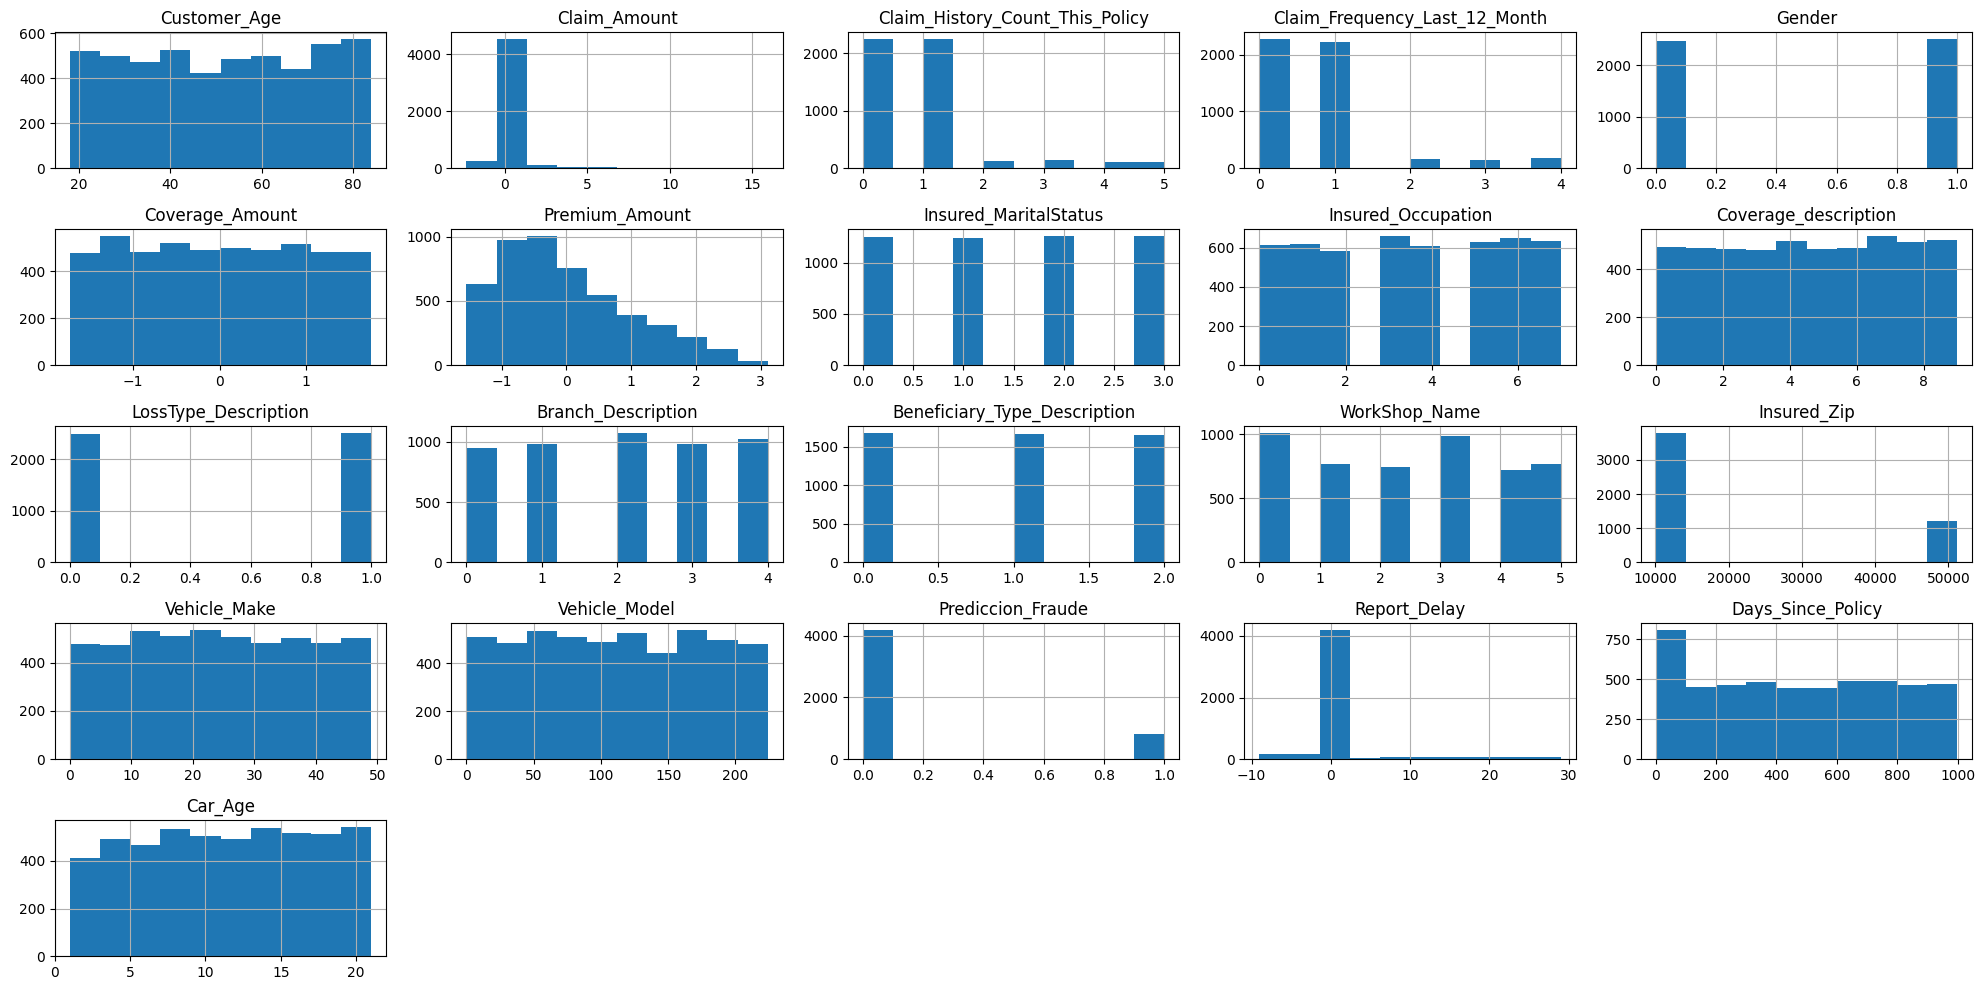

In [7]:
# ==============================================================================
# 1.2 EDA - Análisis exploratorio de los datos
# ==============================================================================
# Dibujar histogramas de todos los atributos
plt.rcParams['figure.figsize'] = [20, 10]
df.hist()
plt.subplots_adjust(wspace=0.5, hspace=0.5) # Add spacing between subplots
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [8]:
print(f'la cantidad de registros: {df.shape[0]:,}')
print(f'la cantidad de columnas:  {df.shape[1]}')

la cantidad de registros: 5,000
la cantidad de columnas:  22


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Customer_Age                     5000 non-null   int64  
 1   Claim_Amount                     5000 non-null   float64
 2   Claim_History_Count_This_Policy  5000 non-null   int64  
 3   Claim_Frequency_Last_12_Month    5000 non-null   int64  
 4   Claim_Description                5000 non-null   object 
 5   Gender                           5000 non-null   int64  
 6   Coverage_Amount                  5000 non-null   float64
 7   Premium_Amount                   5000 non-null   float64
 8   Insured_MaritalStatus            5000 non-null   int64  
 9   Insured_Occupation               5000 non-null   int64  
 10  Coverage_description             5000 non-null   int64  
 11  LossType_Description             5000 non-null   int64  
 12  Branch_Description  

In [10]:
df.describe()

,Customer_Age,Claim_Amount,Claim_History_Count_This_Policy,Claim_Frequency_Last_12_Month,Gender,Coverage_Amount,Premium_Amount,Insured_MaritalStatus,Insured_Occupation,Coverage_description,...,Branch_Description,Beneficiary_Type_Description,WorkShop_Name,Insured_Zip,Vehicle_Make,Vehicle_Model,Prediccion_Fraude,Report_Delay,Days_Since_Policy,Car_Age
count,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,51.445800,2.842171e-17,0.790000,0.744800,0.503800,1.662670e-16,1.364242e-16,1.505000,3.538400,4.569800,...,2.028200,0.993200,2.387400,20494.476000,24.520400,111.153000,0.163000,2.003600,468.814200,10.817800
std,19.617993,1.000100e+00,1.056467,0.932227,0.500036,1.000100e+00,1.000100e+00,1.119744,2.292155,2.882775,...,1.402212,0.816387,1.723228,17232.288568,14.289017,64.312353,0.369403,5.511593,306.620784,5.706445
min,18.000000,-2.328331e+00,0.000000,0.000000,0.000000,-1.727980e+00,-1.543955e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,10101.000000,0.000000,0.000000,0.000000,-9.000000,1.000000,1.000000
25%,34.000000,-3.505800e-01,0.000000,0.000000,0.000000,-8.649996e-01,-7.812993e-01,1.000000,2.000000,2.000000,...,1.000000,0.000000,1.000000,10509.000000,12.000000,57.000000,0.000000,0.000000,199.000000,6.000000
50%,51.000000,-2.209504e-01,1.000000,1.000000,1.000000,-5.240217e-03,-2.078139e-01,2.000000,4.000000,5.000000,...,2.000000,1.000000,2.000000,10580.000000,24.000000,110.000000,0.000000,1.000000,465.000000,11.000000
75%,69.000000,1.858035e-02,1.000000,1.000000,1.000000,8.543056e-01,6.192556e-01,3.000000,6.000000,7.000000,...,3.000000,2.000000,4.000000,11503.000000,37.000000,166.000000,0.000000,2.000000,737.000000,16.000000
max,84.000000,1.593471e+01,5.000000,4.000000,1.000000,1.749167e+00,3.105932e+00,3.000000,7.000000,9.000000,...,4.000000,2.000000,5.000000,51200.000000,49.000000,224.000000,1.000000,29.000000,999.000000,21.000000


In [11]:
df.head(20)

,Customer_Age,Claim_Amount,Claim_History_Count_This_Policy,Claim_Frequency_Last_12_Month,Claim_Description,Gender,Coverage_Amount,Premium_Amount,Insured_MaritalStatus,Insured_Occupation,...,Branch_Description,Beneficiary_Type_Description,WorkShop_Name,Insured_Zip,Vehicle_Make,Vehicle_Model,Prediccion_Fraude,Report_Delay,Days_Since_Policy,Car_Age
0,74,-0.358126,0,1,"El 15 de octubre, mientras manejaba por la Av....",1,0.573257,-0.457059,3,5,...,3,1,0,51100,40,163,0,1,112,4
1,44,-0.400989,0,0,"El 24 de octubre, tuve un accidente mientras c...",0,-1.450495,-1.045902,1,0,...,2,0,0,10508,25,196,0,1,654,2
2,23,-0.145810,1,1,"El pasado 15 de octubre, tuve un accidente con...",0,-0.628259,-0.141833,0,5,...,1,0,0,11503,30,161,0,0,469,1
3,48,0.150410,1,0,"El 15 de octubre, mientras manejaba mi vehícul...",0,1.126643,0.386856,2,5,...,1,2,4,11501,33,44,0,1,601,4
4,55,-0.377964,0,0,El pasado 12 de octubre tuve un accidente con ...,1,-1.656487,-1.083339,1,6,...,4,1,0,11503,47,164,0,2,192,3
5,68,0.083114,0,1,"El 22 de octubre, mientras conducía por la Ave...",0,0.673692,-0.417337,2,1,...,3,1,4,10509,28,60,0,2,524,15
6,34,-0.345797,1,0,"El pasado martes, tuve un accidente con mi veh...",1,-1.184959,-0.541836,0,1,...,1,1,5,11503,4,180,0,2,834,18
7,59,-0.029763,4,2,El vehículo se vio involucrado en un incidente...,0,-1.379544,-1.149419,0,1,...,2,1,0,10509,32,25,1,20,5,10
8,20,-0.412814,1,0,"El 15 de octubre, mientras conducía por la aut...",1,-1.288116,-0.580869,0,7,...,0,1,4,10520,34,142,0,2,278,7
9,76,-0.279640,1,0,"El 10 de octubre, tuve un accidente donde mi v...",1,-1.271996,-0.575950,3,7,...,4,1,5,10101,27,54,0,1,791,10


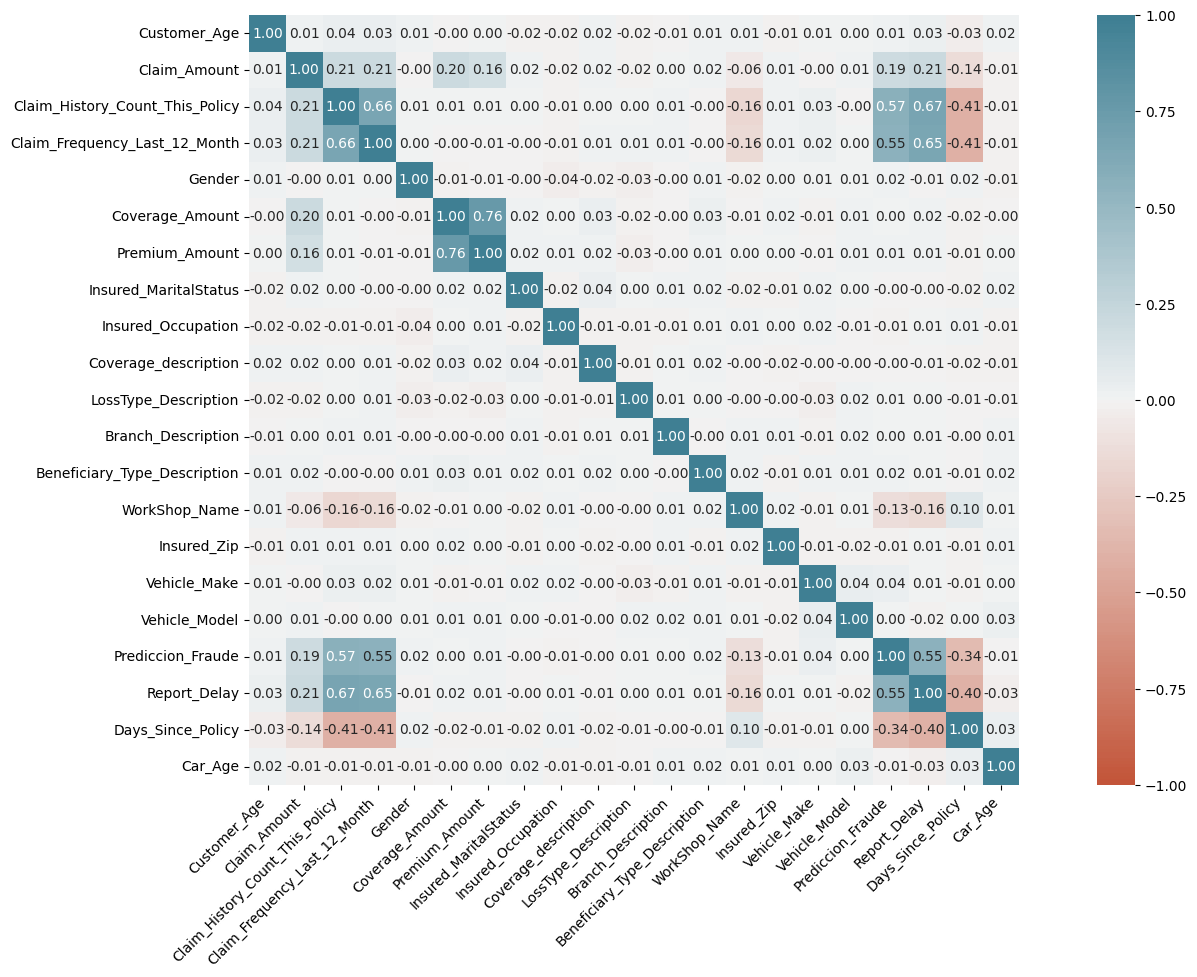

In [12]:
corr= df.corr(numeric_only=True)
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot=True, # mostrar los valores dentro de cada celda
    fmt=".2f" # formato para los valores numericos de la correlacion (2 decimales)
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

In [13]:
# Revisión de datos faltantes
col_total_nulos = df.isnull().sum()
serie_col_nombres = col_total_nulos[col_total_nulos > 0]
display(serie_col_nombres)

# contando los nulos por columna
df.isna().sum()

Series([], dtype: int64)

Customer_Age                       0
Claim_Amount                       0
Claim_History_Count_This_Policy    0
Claim_Frequency_Last_12_Month      0
Claim_Description                  0
Gender                             0
Coverage_Amount                    0
Premium_Amount                     0
Insured_MaritalStatus              0
Insured_Occupation                 0
Coverage_description               0
LossType_Description               0
Branch_Description                 0
Beneficiary_Type_Description       0
WorkShop_Name                      0
Insured_Zip                        0
Vehicle_Make                       0
Vehicle_Model                      0
Prediccion_Fraude                  0
Report_Delay                       0
Days_Since_Policy                  0
Car_Age                            0
dtype: int64

In [14]:
# Revisar valores en cero
(df==0).sum(axis=0)

Customer_Age                          0
Claim_Amount                          0
Claim_History_Count_This_Policy    2255
Claim_Frequency_Last_12_Month      2280
Claim_Description                     0
Gender                             2481
Coverage_Amount                       0
Premium_Amount                        0
Insured_MaritalStatus              1249
Insured_Occupation                  614
Coverage_description                491
LossType_Description               2489
Branch_Description                  949
Beneficiary_Type_Description       1683
WorkShop_Name                      1012
Insured_Zip                           0
Vehicle_Make                         76
Vehicle_Model                        19
Prediccion_Fraude                  4185
Report_Delay                       1383
Days_Since_Policy                     0
Car_Age                               0
dtype: int64

All numerical columns: ['Customer_Age', 'Claim_Amount', 'Claim_History_Count_This_Policy', 'Claim_Frequency_Last_12_Month', 'Gender', 'Coverage_Amount', 'Premium_Amount', 'Insured_MaritalStatus', 'Insured_Occupation', 'Coverage_description', 'LossType_Description', 'Branch_Description', 'Beneficiary_Type_Description', 'WorkShop_Name', 'Insured_Zip', 'Vehicle_Make', 'Vehicle_Model', 'Prediccion_Fraude', 'Report_Delay', 'Days_Since_Policy', 'Car_Age']
big_values_columns column: ['Claim_Amount', 'Coverage_Amount', 'Premium_Amount', 'Insured_Zip', 'Customer_Age']
Other numerical columns (excluding Claim_Amount): ['Claim_History_Count_This_Policy', 'Claim_Frequency_Last_12_Month', 'Gender', 'Insured_MaritalStatus', 'Insured_Occupation', 'Coverage_description', 'LossType_Description', 'Branch_Description', 'Beneficiary_Type_Description', 'WorkShop_Name', 'Vehicle_Make', 'Vehicle_Model', 'Prediccion_Fraude', 'Report_Delay', 'Days_Since_Policy', 'Car_Age']


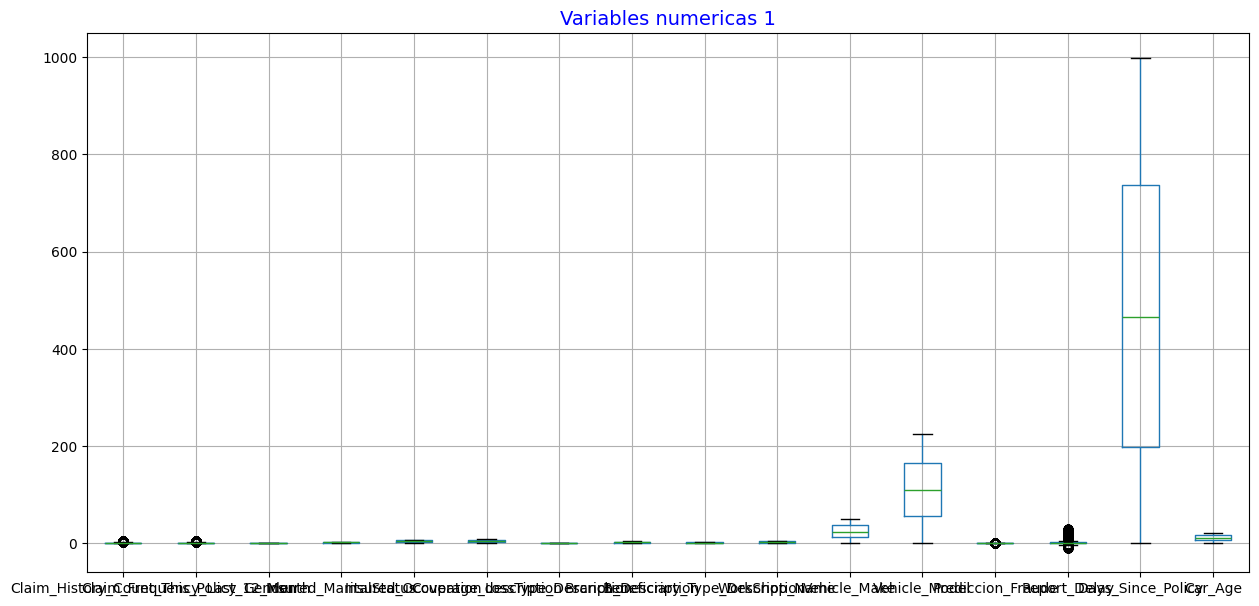

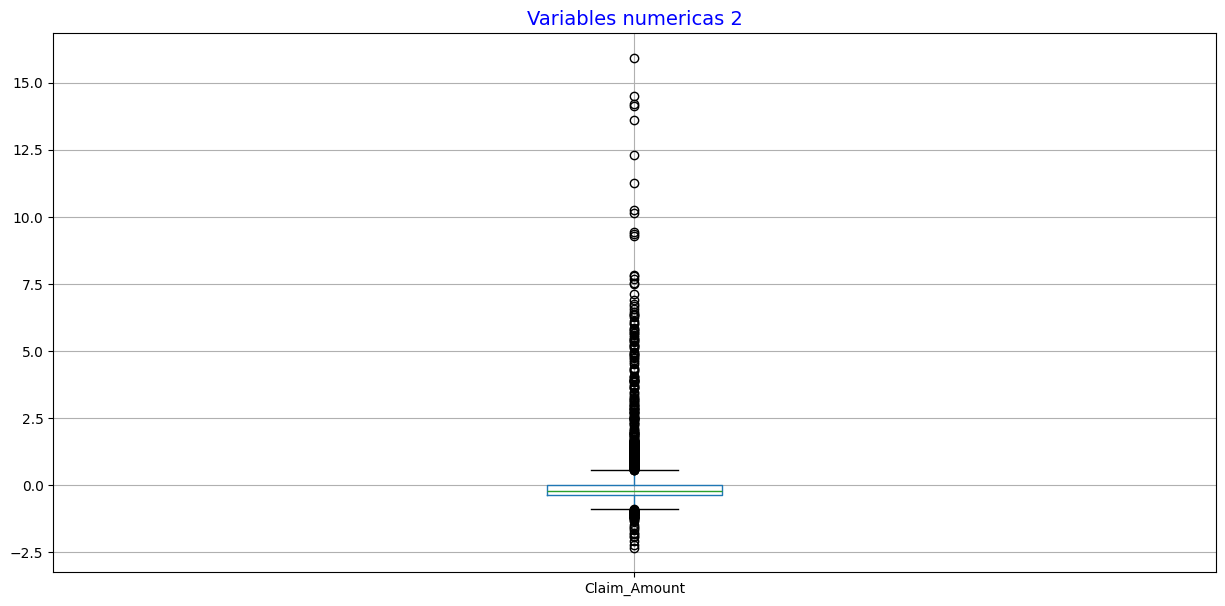

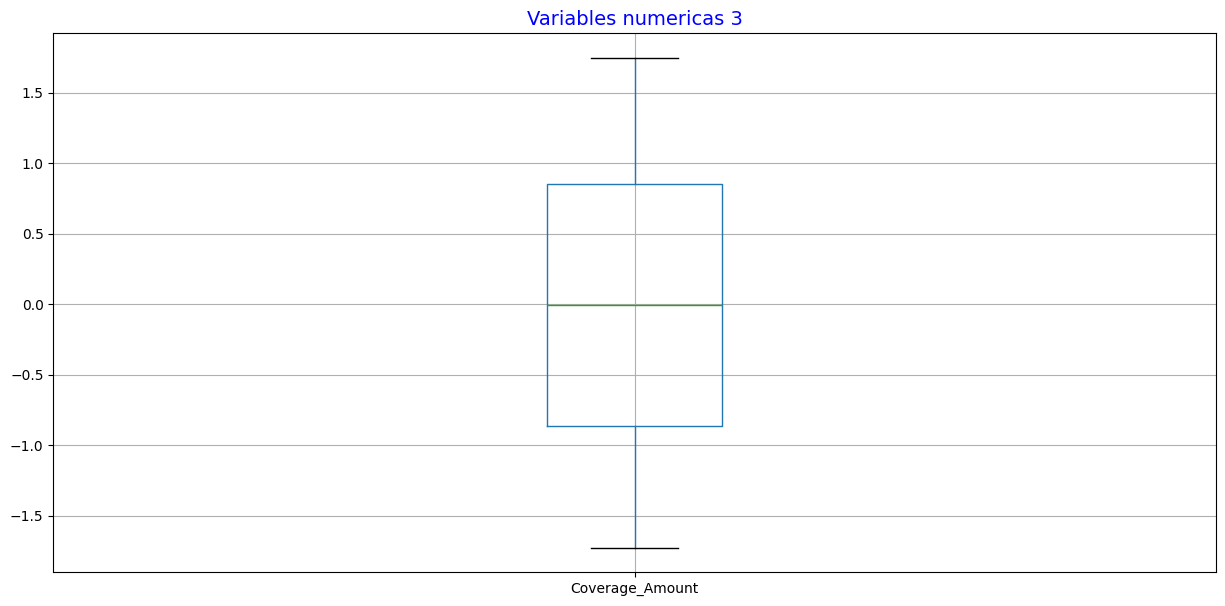

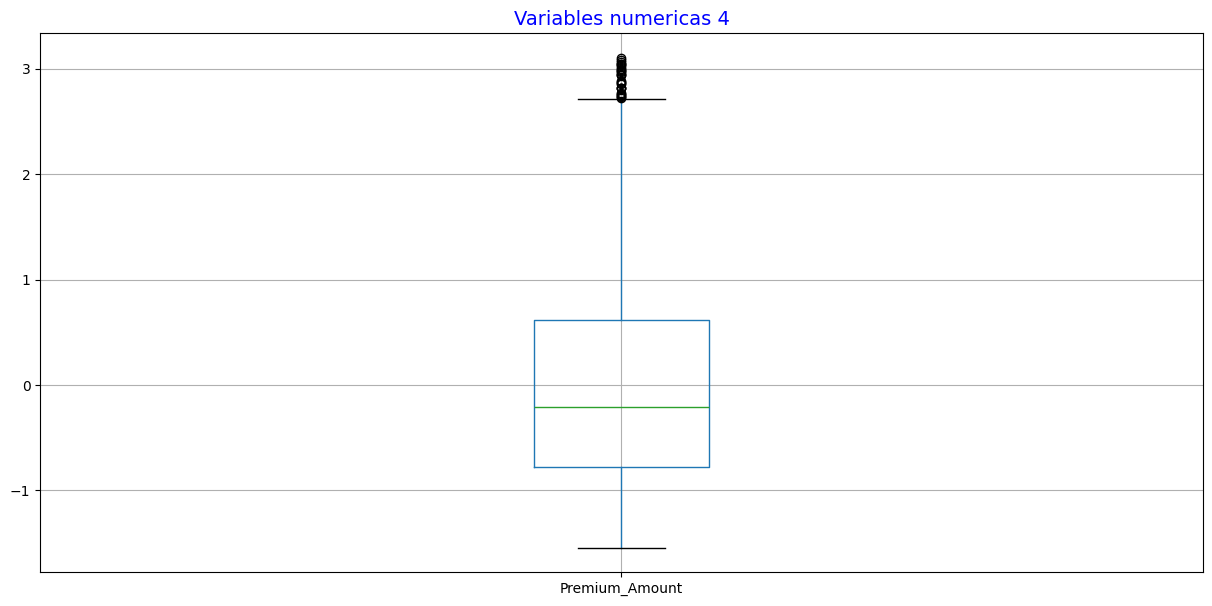

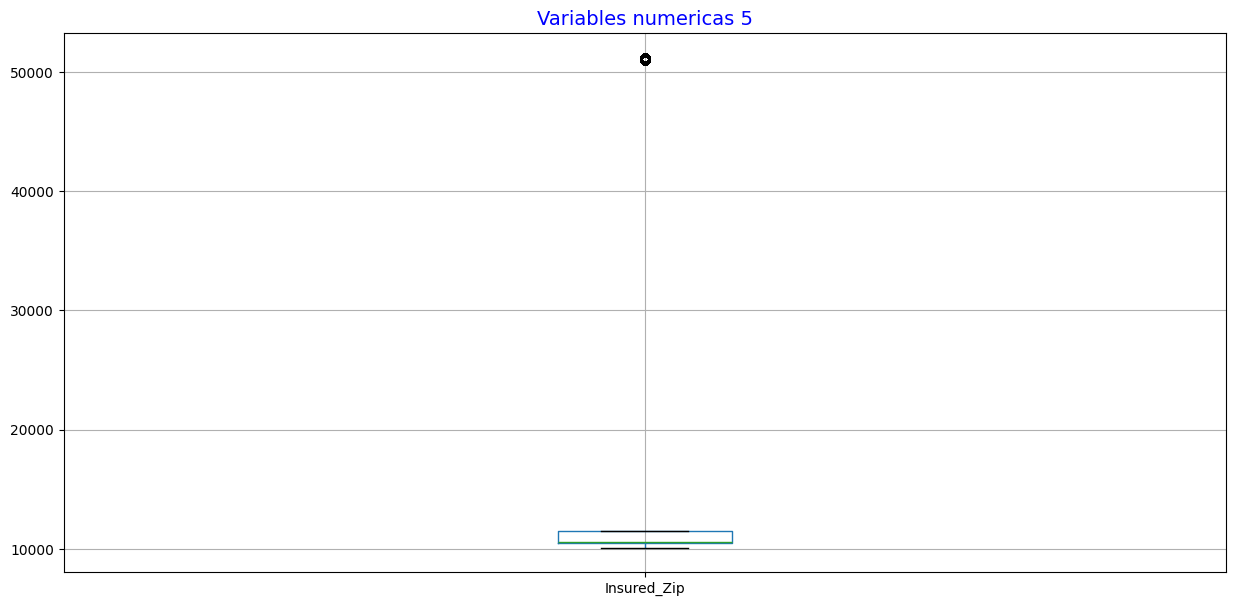

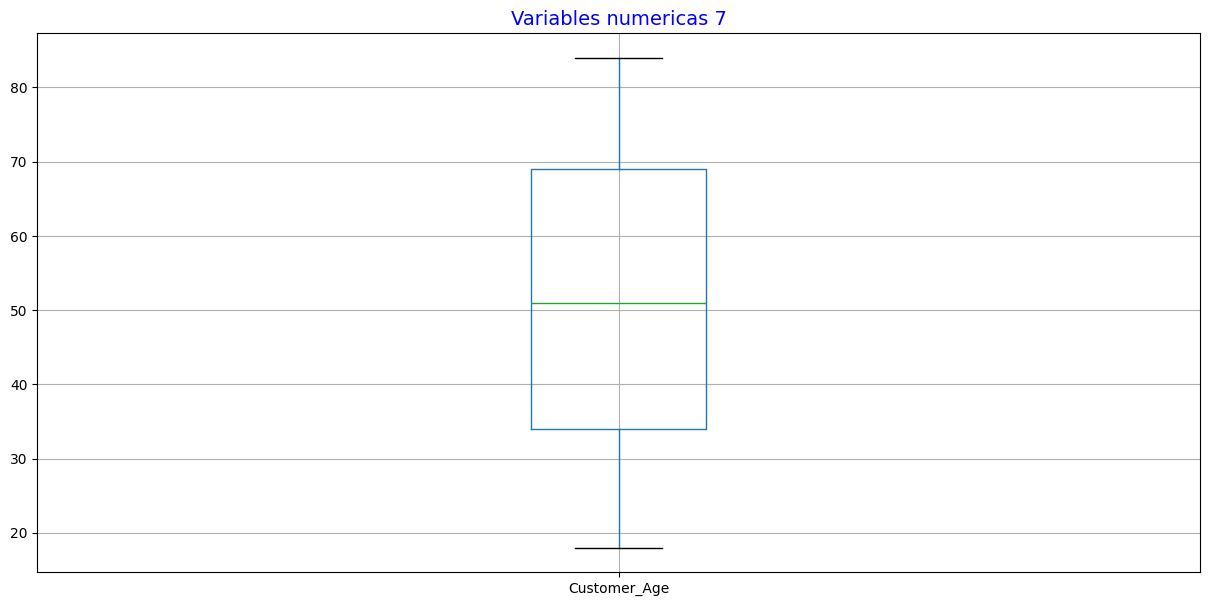

In [15]:
# Se grafican los diagramas de cajas y bigotes de cada una de las variables numéricas
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
big_values_columns = ['Claim_Amount', 'Coverage_Amount', 'Premium_Amount', 'Insured_Zip', 'Customer_Age']
small_numerical_cols = [col for col in numerical_cols if col not in big_values_columns]


print(f"All numerical columns: {numerical_cols}")
print(f"big_values_columns column: {big_values_columns}")
print(f"Other numerical columns (excluding Claim_Amount): {small_numerical_cols}")

boxplot = df[small_numerical_cols].boxplot(figsize=(15,7))
plt.title("Variables numericas 1", fontsize=14, color='blue')
plt.show()
print(' ')

boxplot = df[['Claim_Amount']].boxplot(figsize=(15,7))
plt.title("Variables numericas 2", fontsize=14, color='blue')
plt.show()
print(' ')

boxplot = df[['Coverage_Amount']].boxplot(figsize=(15,7))
plt.title("Variables numericas 3", fontsize=14, color='blue')
plt.show()
print(' ')

boxplot = df[['Premium_Amount']].boxplot(figsize=(15,7))
plt.title("Variables numericas 4", fontsize=14, color='blue')
plt.show()
print(' ')

boxplot = df[['Insured_Zip']].boxplot(figsize=(15,7))
plt.title("Variables numericas 5", fontsize=14, color='blue')
plt.show()
print(' ')


boxplot = df[['Customer_Age']].boxplot(figsize=(15,7))
plt.title("Variables numericas 7", fontsize=14, color='blue')
plt.show()
print(' ')



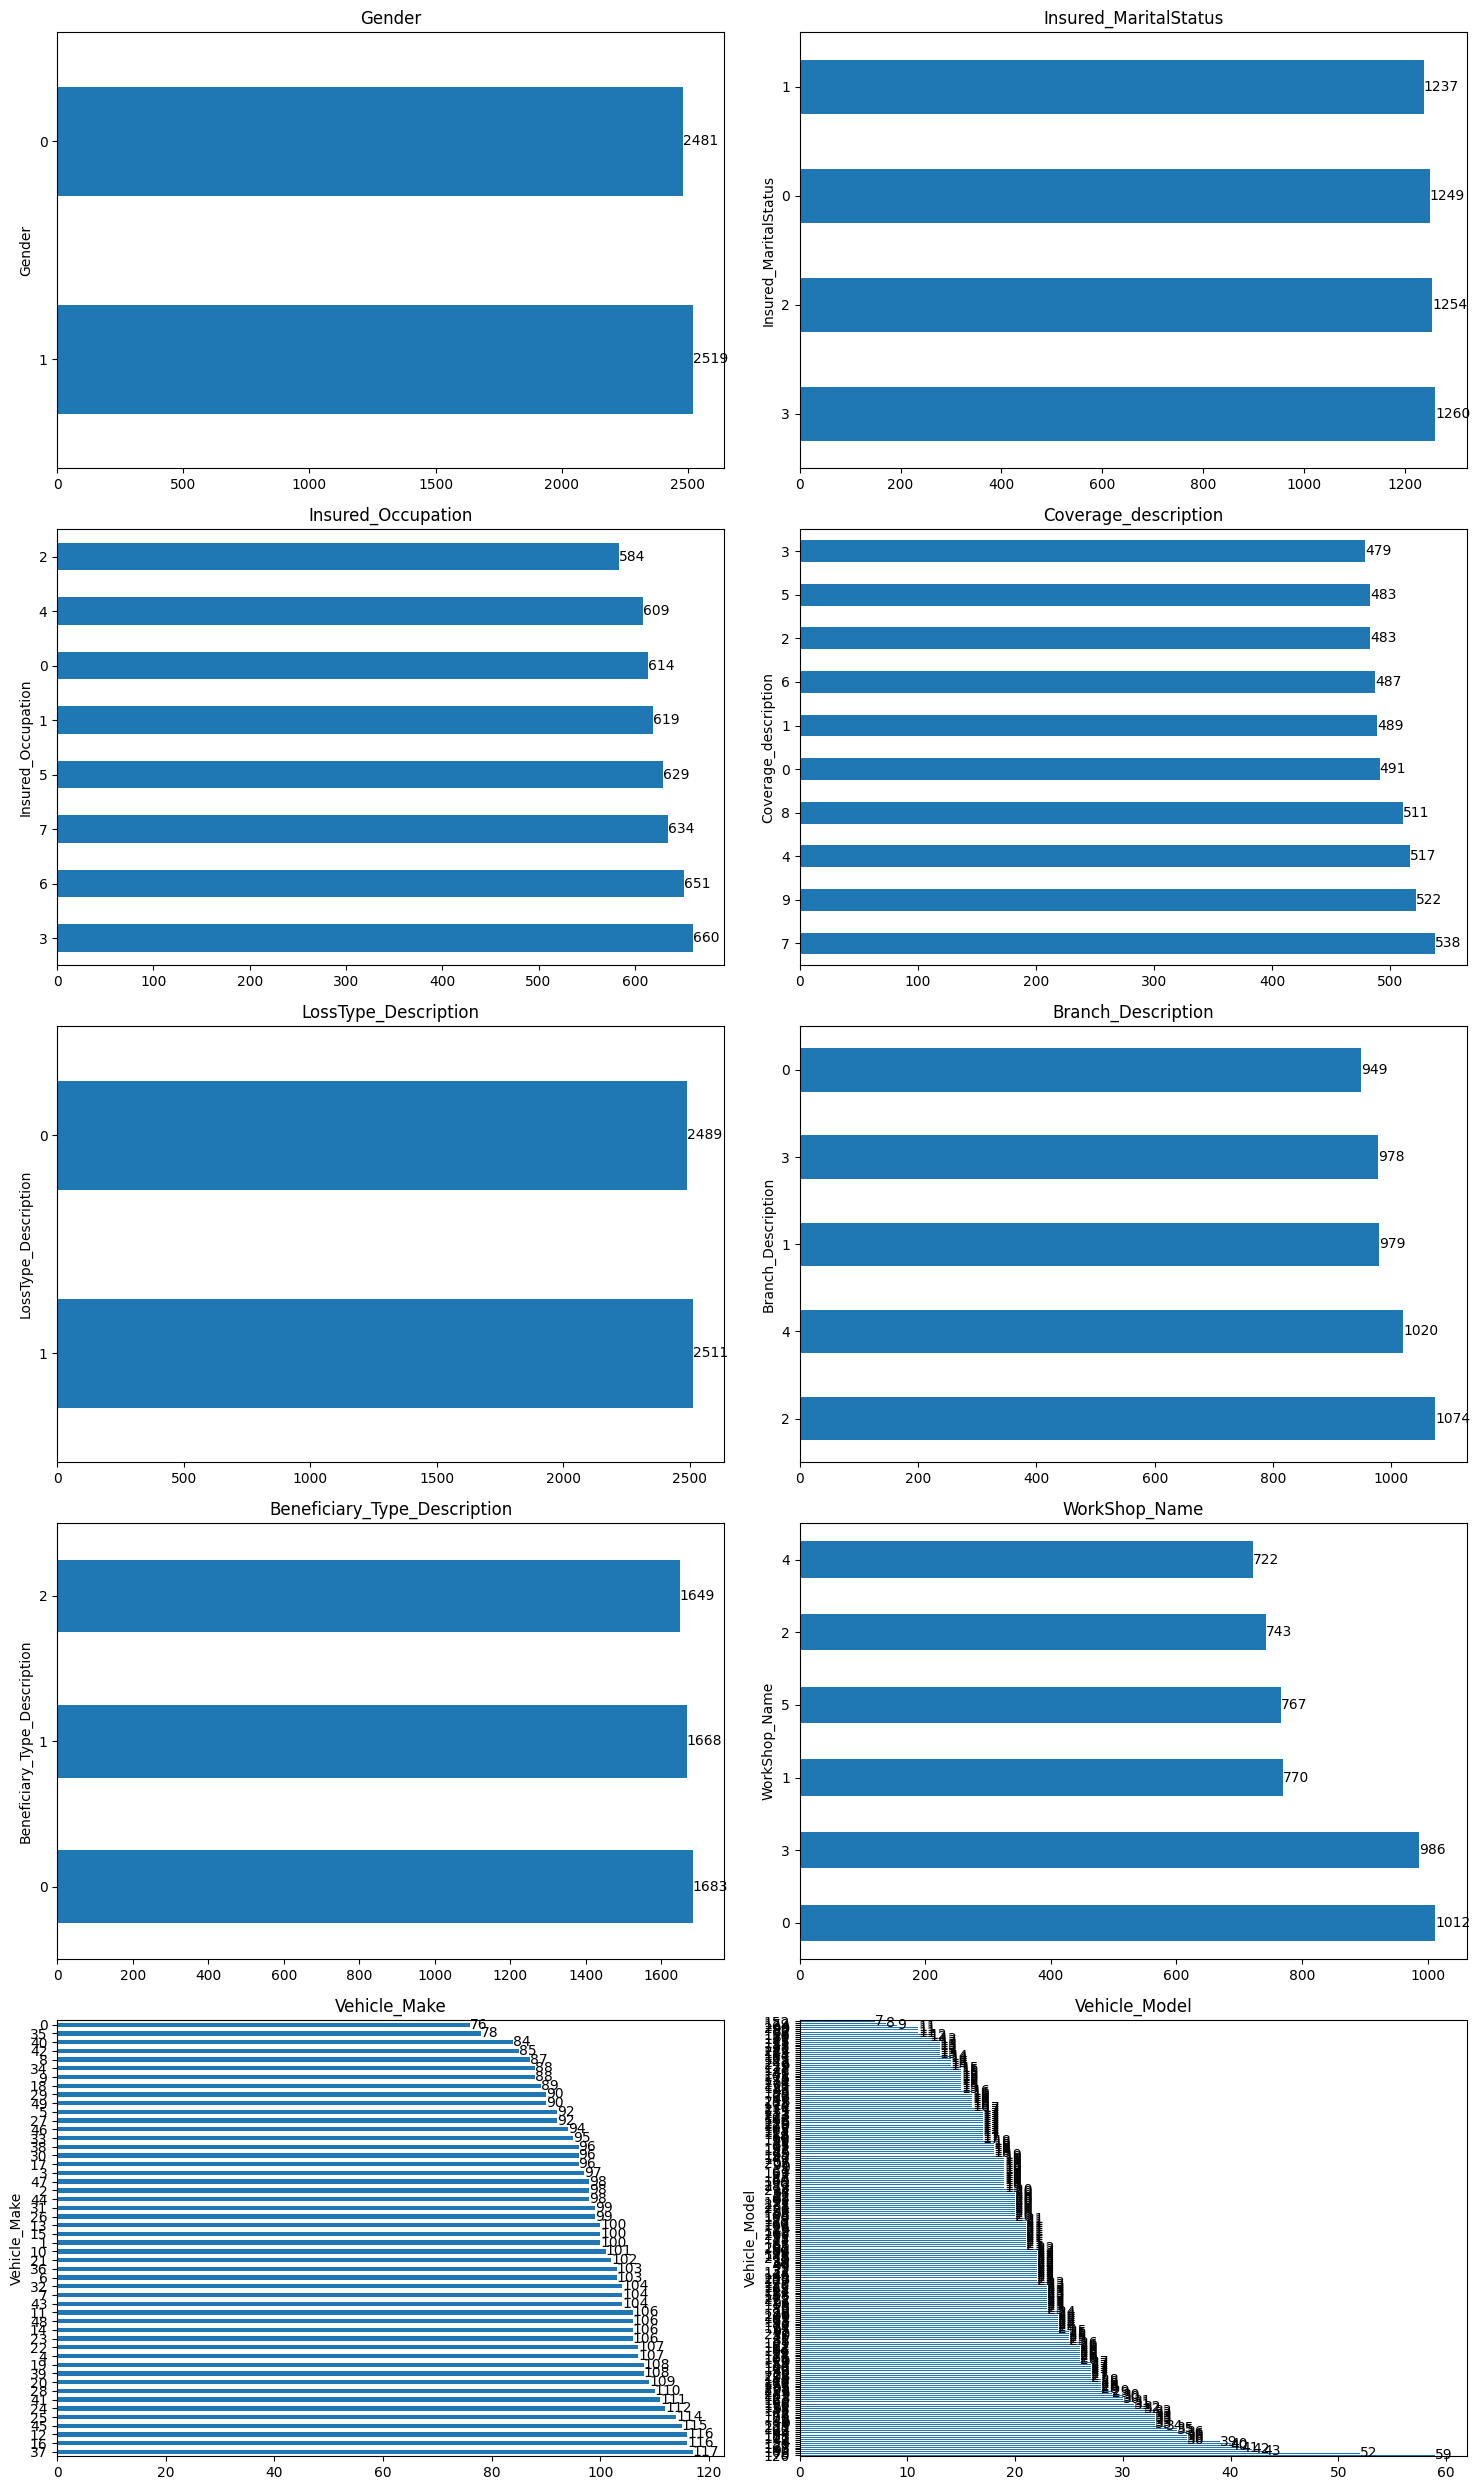

In [16]:
# Se grafican las variables categoricas

lst_var_cat = list(label_encoders.keys()) # Use the keys from label_encoders for categorical columns

# Calculate the number of rows needed for subplots
num_categorical_cols = len(lst_var_cat)
nrows = (num_categorical_cols + 1) // 2  # Divide by 2 and round up for rows
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(15, 5 * nrows)) # Adjust figsize dynamically

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

# Flatten axes for easier iteration if it's a 2D array, otherwise keep as 1D
axes = axes.flatten() if num_categorical_cols > 1 else [axes]

for i, col in enumerate(lst_var_cat):
    if i < len(axes): # Ensure we don't go out of bounds if there are fewer axes than columns
        df[col].value_counts().plot.barh(ax=axes[i])
        axes[i].set_title(col)
        axes[i].bar_label(axes[i].containers[0])

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Número de registros por clase


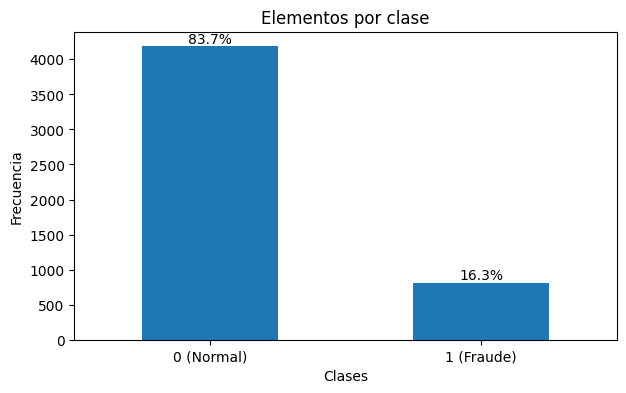

In [17]:
# Distribución por Clase

class_labels = ['0 (Normal)', '1 (Fraude)']

print("Número de registros por clase")
# Obtener el conteo de cada clase y ordenarlo por índice
class_counts = df['Prediccion_Fraude'].value_counts().sort_index()
ax = class_counts.plot(kind='bar',
                        figsize=(7,4),
                        title="Elementos por clase")

ax.set_xlabel("Clases")
ax.set_ylabel("Frecuencia")
ax.set_xticklabels(class_labels)
plt.xticks(rotation=0)

# Añadir los porcentajes a las barras
total_records = df.shape[0]
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total_records)
    x1 = p.get_x() + p.get_width() / 2
    y1 = p.get_height()
    ax.annotate(percentage, (x1, y1), ha='center', va='bottom') # Colocar el texto un poco por encima de la barra

plt.show()

# El dataset está desbalanceado por la natural del dato, lo normal es que no sea fraude


Analizando patrones psicológicos en los textos...

¡Gráficas guardadas como 'dashboard_marcadores_fraude_completo.png' listas para la presentación!


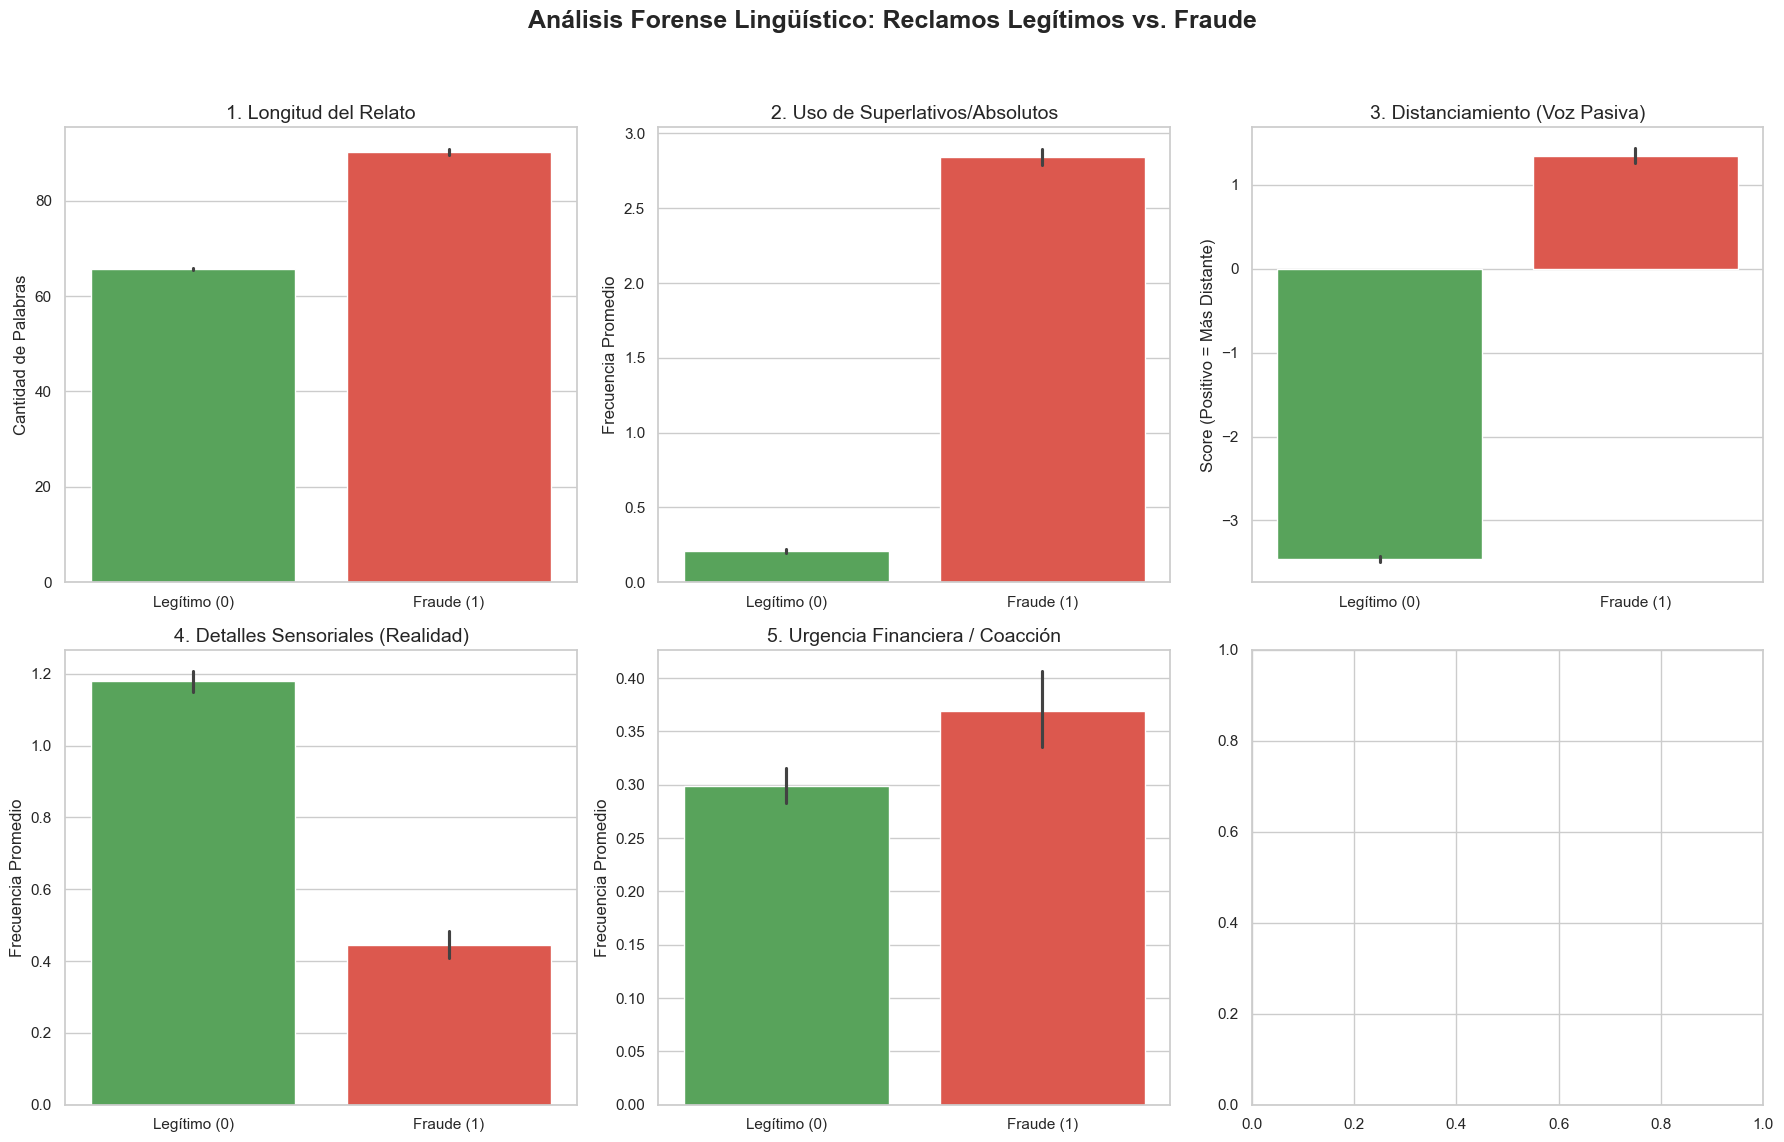

In [18]:
# Configuración visual para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Limpiar nulos por si el ruido inyectó algún NaN en la descripción
df['Claim_Description'] = df['Claim_Description'].fillna("")

# Crear una copia del DataFrame para añadir las nuevas características lingüísticas
df_nlp = df.copy()

# 2. Definir funciones de extracción de características lingüísticas
def contar_palabras(texto):
    return len(str(texto).split())

def contar_superlativos(texto):
    # Palabras que denotan exceso de justificación
    patron = r'\b(absolutamente|completamente|totalmente|perfectamente|exactamente|excesivamente|definitivamente|imposible)\b'
    matches = re.findall(patron, str(texto).lower())
    return len(matches)

def indice_distanciamiento(texto):
    texto = str(texto).lower()
    # Pronombres personales (El cliente asume la situación)
    personales = len(re.findall(r'\b(yo|me|mi|mis)\b', texto))
    # Lenguaje pasivo/distante (El cliente se aleja del accidente)
    impersonales = len(re.findall(r'\b(el vehículo|la unidad|el auto|se produjo|fue impactado|resultó)\b', texto))

    # Retornamos la diferencia: un número positivo alto significa más distanciamiento
    # Si usa muchos "yo/me", el número será negativo o cercano a cero.
    return impersonales - personales

def indice_evasivas(texto):
    patron = r'\b(creo|parece|quizás|tal vez|aparentemente|me pareció|supongo|alrededor de|mas o menos)\b'
    return len(re.findall(patron, str(texto).lower()))

def indice_sensorial(texto):
    patron = r'\b(escuché|sonó|vi|fuerte|estruendo|ruido|olor|frenazo|golpe|impacto|tembló)\b'
    return len(re.findall(patron, str(texto).lower()))

def indice_urgencia(texto):
    patron = r'\b(rápido|urgente|necesito|dinero|paguen|abogado|inaceptable|exijo|demanda|injusto)\b'
    return len(re.findall(patron, str(texto).lower()))


# 3. Aplicar funciones al dataset (en la copia df_nlp)
print("Analizando patrones psicológicos en los textos...")
df_nlp['Word_Count'] = df_nlp['Claim_Description'].apply(contar_palabras)
df_nlp['Superlativos_Count'] = df_nlp['Claim_Description'].apply(contar_superlativos)
df_nlp['Score_Distanciamiento'] = df_nlp['Claim_Description'].apply(indice_distanciamiento)
#df_nlp['Score_Evasivas'] = df_nlp['Claim_Description'].apply(indice_evasivas)
df_nlp['Score_Sensorial'] = df_nlp['Claim_Description'].apply(indice_sensorial)
df_nlp['Score_Urgencia'] = df_nlp['Claim_Description'].apply(indice_urgencia)

# 4. Agrupar y comparar estadísticas entre Legítimos (0) y Fraudes (1) usando df_nlp
estadisticas = df_nlp.groupby('Prediccion_Fraude')[
    [
        'Word_Count',
        'Superlativos_Count',
        'Score_Distanciamiento',
        #'Score_Evasivas',
        'Score_Sensorial',
        'Score_Urgencia'
    ]
    ].mean().round(2)

#print("\n--- RESULTADOS DE LA VALIDACIÓN LINGÜÍSTICA ---")
#print("Clase 0 = Legítimo | Clase 1 = Fraude\n")
#print(estadisticas)

# Configuración visual
sns.set_theme(style="whitegrid")
# Ajustamos el tamaño de la figura para acomodar 6 gráficas (2 filas x 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Análisis Forense Lingüístico: Reclamos Legítimos vs. Fraude', fontsize=18, fontweight='bold')

# Lista de configuración para iterar y crear los gráficos limpiamente
metricas = [
    ('Word_Count', '1. Longitud del Relato', 'Cantidad de Palabras'),
    ('Superlativos_Count', '2. Uso de Superlativos/Absolutos', 'Frecuencia Promedio'),
    ('Score_Distanciamiento', '3. Distanciamiento (Voz Pasiva)', 'Score (Positivo = Más Distante)'),
    # ('Score_Evasivas', '4. Lenguaje Evasivo (Duda)', 'Frecuencia Promedio'),
    ('Score_Sensorial', '4. Detalles Sensoriales (Realidad)', 'Frecuencia Promedio'),
    ('Score_Urgencia', '5. Urgencia Financiera / Coacción', 'Frecuencia Promedio')
]

# Aplanamos la matriz de ejes para iterar fácilmente (de 2x3 a un array de 6)
axes = axes.flatten()

# Generar cada subgráfico usando df_nlp
for i, (columna, titulo, ylabel) in enumerate(metricas):
    # Usamos verde (#4CAF50) para Legítimo y rojo (#F44336) para Fraude
    sns.barplot(x='Prediccion_Fraude', y=columna, data=df_nlp, ax=axes[i], palette=['#4CAF50', '#F44336'], hue='Prediccion_Fraude', legend=False)
    axes[i].set_title(titulo, fontsize=14)
    # Explicitly set ticks before labels to avoid UserWarning
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Legítimo (0)', 'Fraude (1)'])
    axes[i].set_ylabel(ylabel)
    axes[i].set_xlabel('')

# Ajustar el espaciado para que no se solapen los títulos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("dashboard_marcadores_fraude_completo.png", dpi=300)
print("\n¡Gráficas guardadas como 'dashboard_marcadores_fraude_completo.png' listas para la presentación!")
plt.show()

In [ ]:
import gc
import numpy as np
from tqdm import tqdm # Para ver la barra de progreso

# ==============================================================================
# 2. PROCESAMIENTO NLP CON PYTORCH Y DISTILBERT (FEATURE EXTRACTION)
# ==============================================================================
print("\n[*] 2. Descargando modelo DistilBERT Nativo (PyTorch)...")

# Carga del tokenizador y modelo pre-entrenado
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")
distilbert_model = AutoModel.from_pretrained("distilbert-base-multilingual-cased")
distilbert_model.eval()

# ----------------- DETECCIÓN UNIVERSAL DE HARDWARE -----------------
# 1. Primero busca NVIDIA (CUDA) - Ideal para Google Colab o PCs potentes
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("[*] Hardware detectado: NVIDIA GPU (CUDA)")
    
# 2. Si no hay NVIDIA, busca Apple Silicon (M1/M2/M3/M4)
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("[*] Hardware detectado: Apple Silicon (Metal/MPS)")
    
# 3. Si no encuentra ninguna GPU compatible, usa el procesador normal
else:
    device = torch.device("cpu")
    print("[*] Hardware detectado: CPU tradicional (Atención: será más lento)")

distilbert_model.to(device)

# ----------------- EXTRACCIÓN CON CONTROL DE MEMORIA -----------------
def extract_embeddings(text_list, batch_size=16):
    all_embeddings = []
    
    for i in tqdm(range(0, len(text_list), batch_size), desc="Procesando Textos"):
        batch = text_list[i:i+batch_size]
        
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=120, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = distilbert_model(**inputs)

        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)

        # Limpieza profunda de memoria adaptada al hardware actual
        del inputs, outputs, cls_embeddings
        
        if device.type == 'mps':
            torch.mps.empty_cache()  # Limpia la VRAM en la Mac
        elif device.type == 'cuda':
            torch.cuda.empty_cache() # Limpia la VRAM en Colab/NVIDIA
            
        gc.collect() # Recolector de basura de Python

    return np.vstack(all_embeddings)

print("\n[*] Convirtiendo textos a Embeddings de DistilBERT...")
X_text_embeddings = extract_embeddings(text_data)
print(f"\n[*] Embeddings generados con forma: {X_text_embeddings.shape} (Textos, Dimensiones)")


[*] 2. Descargando modelo DistilBERT Nativo (PyTorch)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


: 

: 

: 

In [ ]:
# ==============================================================================
# 3. DIVISION DE DATOS: TRAIN, VALIDATION, META Y TEST
# ==============================================================================
print("\n[*] 3. Dividiendo datos de forma estratificada...")

# División en 4 conjuntos manteniendo la proporción de clases (stratify)
# Esta división es crucial para los modelos de Stacking:
# - idx_train/y_train: Para entrenar los modelos base (XGBoost y Red Neuronal NLP).
# - idx_val/y_val: Para validar y ajustar hiperparámetros de los modelos base (ej. early stopping).
# - idx_meta/y_meta: Para generar las predicciones 'out-of-fold' de los modelos base,
#                    que luego se usarán como entradas para entrenar el Meta-Learner.
#                    Esto evita el 'data leakage' desde los modelos base al Meta-Learner.
# - idx_test/y_test: Para la evaluación final y no sesgada del rendimiento del modelo híbrido completo.
indices = np.arange(len(y))
idx_temp, idx_test, y_temp, y_test = train_test_split(indices, y, test_size=0.20, random_state=42, stratify=y)
idx_base, idx_meta, y_base, y_meta = train_test_split(idx_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
idx_train, idx_val, y_train, y_val = train_test_split(idx_base, y_base, test_size=0.20, random_state=42, stratify=y_base)

# Asignación de divisiones a los datos tabulares
X_tab_train, X_tab_val, X_tab_meta, X_tab_test = X_tab[idx_train], X_tab[idx_val], X_tab[idx_meta], X_tab[idx_test]

# Asignación de divisiones a los datos de texto (Embeddings)
X_text_train = X_text_embeddings[idx_train]
X_text_val   = X_text_embeddings[idx_val]
X_text_meta  = X_text_embeddings[idx_meta]
X_text_test  = X_text_embeddings[idx_test]


In [ ]:
print(f"Cantidad de elementos para entrenamiento: {len(idx_train)}")
print(f"Cantidad de elementos para validacion: {len(idx_val)}")
print(f"Cantidad de elementos para meta: {len(idx_meta)}")
print(f"Cantidad de elementos para test: {len(idx_test)}")

In [ ]:
# ==============================================================================
# FUNCIONES DE EVALUACIÓN
# ==============================================================================
def evaluate_and_plot_metrics(y_true, y_pred_prob, model_name, threshold=0.5, history=None):
    """
    Calcula métricas de clasificación y genera gráficos (Matriz de Confusión y Curva ROC).
    Opcionalmente, grafica la evolución del accuracy y loss durante el entrenamiento
    si se proporciona un objeto history de Keras.

    Args:
        y_true (array): Etiquetas reales.
        y_pred_prob (array): Probabilidades predichas por el modelo.
        model_name (str): Nombre del modelo evaluado (para títulos de gráficos).
        threshold (float): Umbral para convertir probabilidad en clase binaria.
        history (tensorflow.keras.callbacks.History, optional): Objeto History de Keras
                                                            que contiene los registros de entrenamiento.
    """
    if history:
        # Gráficos de Accuracy y Loss
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Plot training & validation accuracy values
        ax1.plot(history.history['accuracy'])
        ax1.plot(history.history['val_accuracy'])
        ax1.set_title(f'Accuracy del Modelo {model_name}')
        ax1.set_ylabel('Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.legend(['Train', 'Validation'], loc='upper left')

        # Plot training & validation loss values
        ax2.plot(history.history['loss'])
        ax2.plot(history.history['val_loss'])
        ax2.set_title(f'Loss del Modelo {model_name}')
        ax2.set_ylabel('Loss')
        ax2.set_xlabel('Epoch')
        ax2.legend(['Train', 'Validation'], loc='upper left')
        plt.show()

    y_pred_bin = (y_pred_prob > threshold).astype(int)
    print(f"\n" + "="*60 + f"\n📈 EVALUACIÓN EN TEST SET: {model_name}\n" + "="*60)
    print(f"F1-Score: {f1_score(y_true, y_pred_bin):.4f} | AUC-ROC: {roc_auc_score(y_true, y_pred_prob):.4f}\n")
    print(classification_report(y_true, y_pred_bin, target_names=['Normal', 'Fraude']))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Matriz de confusión
    sns.heatmap(confusion_matrix(y_true, y_pred_bin), annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Matriz Confusión - {model_name}')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y_true, y_pred_prob):.4f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title(f'Curva ROC - {model_name}')
    axes[1].legend(loc="lower right")
    plt.show()


In [ ]:
# ==============================================================================
# 4. MODELO 1: XGBOOST (DATOS TABULARES)
# ==============================================================================
print("\n🧠 ENTRENANDO XGBoost (Tabular)...")
# scale_pos_weight ayuda a XGBoost a penalizar más los errores en la clase minoritaria (fraude)
xgb_model = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.05, max_depth=6,
    scale_pos_weight=float(np.sum(y_train==0)/np.sum(y_train==1)),
    eval_metric=["logloss", "error"]
)

model_tab = xgb_model.fit(X_tab_train, y_train, eval_set=[(X_tab_train, y_train), (X_tab_val, y_val)], verbose=True)
evaluate_and_plot_metrics(y_test, xgb_model.predict_proba(X_tab_test)[:, 1], "XGBoost (Tabular)")


In [ ]:
# ==============================================================================
# 5. MODELO 2: RED NEURONAL DE KERAS (Recibiendo Embeddings)
# ==============================================================================
print("\n🧠 ENTRENANDO RED NEURONAL (Sobre Embeddings de DistilBERT)...")

# Arquitectura densa para clasificar los vectores de 768 dimensiones
input_text = Input(shape=(768,), name="text_embedding_input")
x = Dense(128, activation='relu')(input_text)
x = Dropout(0.5)(x) # Previene el sobreajuste (overfitting)
x = Dense(32, activation='relu')(x)
x = Dropout(0.4)(x)
output_text = Dense(1, activation='sigmoid')(x)

nn_text_model = Model(inputs=input_text, outputs=output_text)
nn_text_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Detiene el entrenamiento si no hay mejora en validación para evitar overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# Cálculo de pesos para lidiar con el desbalance de clases
class_weights_dict = dict(enumerate(class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

nn_text_model.summary()
# Entrenamiento rápido (los embeddings pesados ya fueron pre-calculados)
history_nn = nn_text_model.fit(
    X_text_train,
    y_train,
    validation_data=(X_text_val, y_val),
    epochs=5, #25
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping],
    verbose=1
)

evaluate_and_plot_metrics(y_test, nn_text_model.predict(X_text_test, verbose=0).flatten(), "NN NLP (Features DistilBERT)", history=history_nn)


In [ ]:
# ==============================================================================
# 6. MODELO 3: META-LEARNER (STACKING ENSEMBLE)
# ==============================================================================
print("\n🧠 ENTRENANDO MODELO HÍBRIDO (META-LEARNER)...")

# Generación de predicciones Out-of-Fold para entrenar el Meta-Learner
pred_meta_xgb = xgb_model.predict_proba(X_tab_meta)[:, 1]
pred_meta_nn = nn_text_model.predict(X_text_meta, verbose=0).flatten()

# Arquitectura del Meta-Learner (Red pequeña que toma las 2 probabilidades como entrada)
meta_input = Input(shape=(2,), name="meta_input")
x = Dense(8, activation='relu')(meta_input)
meta_output = Dense(1, activation='sigmoid')(x)

meta_nn = Model(inputs=meta_input, outputs=meta_output)
meta_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

meta_nn.summary()
# Entrenamiento del ensamble
history_meta_nn = meta_nn.fit(
    np.column_stack((pred_meta_xgb, pred_meta_nn)),
    y_meta,
    validation_split=0.2,
    epochs=20, #30 17
    verbose=1
)

def predecir_fraude_stacking(X_tab_nuevo, texto_nuevo_str):
    """
    Ejecuta el pipeline completo de predicción para datos nuevos.

    Args:
        X_tab_nuevo (array): Datos tabulares preprocesados.
        texto_nuevo_str (list): Lista con el texto crudo de la descripción.

    Returns:
        tuple: (Probabilidad global del ensemble, prob. XGBoost, prob. NN de texto)
    """
    p1 = xgb_model.predict_proba(X_tab_nuevo)[:, 1]

    # Extracción en vivo del embedding y predicción
    emb_nuevo = extract_embeddings(texto_nuevo_str)
    p2 = nn_text_model.predict(emb_nuevo, verbose=0).flatten()

    meta_in = np.column_stack((p1, p2))
    return meta_nn.predict(meta_in, verbose=0).flatten(), p1[0], p2[0]

pred_test_stacking, _, _ = predecir_fraude_stacking(X_tab_test, df['Claim_Description'].iloc[idx_test].tolist())
evaluate_and_plot_metrics(y_test, pred_test_stacking, "Modelo Híbrido Final", history=history_meta_nn)


In [ ]:
# Comparar las metricas del modelo XGBoost versus el Hibrido Final

# Obtener predicciones para el modelo XGBoost
prob_xgb_test = xgb_model.predict_proba(X_tab_test)[:, 1]
y_pred_xgb_bin = (prob_xgb_test > 0.5).astype(int)
f1_xgb = f1_score(y_test, y_pred_xgb_bin)
auc_xgb = roc_auc_score(y_test, prob_xgb_test)

# Obtener predicciones para el modelo Híbrido Final (Stacking)
prob_stack_test, _, _ = predecir_fraude_stacking(X_tab_test, df['Claim_Description'].iloc[idx_test].tolist())
y_pred_stack_bin = (prob_stack_test > 0.5).astype(int)
f1_stack = f1_score(y_test, y_pred_stack_bin)
auc_stack = roc_auc_score(y_test, prob_stack_test)

print("\n--- Comparación de Métricas de Modelos ---")
print(f"XGBoost Model:")
print(f"  F1-Score: {f1_xgb:.4f}")
print(f"  AUC-ROC: {auc_xgb:.4f}")
print("\nHybrid Final Model (Stacking):")
print(f"  F1-Score: {f1_stack:.4f}")
print(f"  AUC-ROC: {auc_stack:.4f}")

print("\n--- Conclusión ---")
if f1_stack > f1_xgb:
    print("El Modelo Híbrido Final tiene un mejor F1-Score.")
elif f1_xgb > f1_stack:
    print("El Modelo XGBoost tiene un mejor F1-Score.")
else:
    print("Ambos modelos tienen F1-Scores similares.")

if auc_stack > auc_xgb:
    print("El Modelo Híbrido Final tiene un mejor AUC-ROC.")
elif auc_xgb > auc_stack:
    print("El Modelo XGBoost tiene un mejor AUC-ROC.")
else:
    print("Ambos modelos tienen AUC-ROC similares.")

# Visualización de la comparación
metrics_data = {
    'Model': ['XGBoost', 'Hybrid Final'],
    'F1-Score': [f1_xgb, f1_stack],
    'AUC-ROC': [auc_xgb, auc_stack]
}
metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot F1-Score
sns.barplot(x='Model', y='F1-Score', data=metrics_df, ax=axes[0], palette=['skyblue', 'lightcoral'], hue='Model', legend=False)
axes[0].set_title('Comparación de F1-Score')
axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(0, 1) # Set y-axis limit for better comparison
for index, row in metrics_df.iterrows():
    axes[0].text(row.name, row['F1-Score'], round(row['F1-Score'], 4), color='black', ha="center", va='bottom')

# Plot AUC-ROC
sns.barplot(x='Model', y='AUC-ROC', data=metrics_df, ax=axes[1], palette=['skyblue', 'lightcoral'], hue='Model', legend=False)
axes[1].set_title('Comparación de AUC-ROC')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim(0, 1) # Set y-axis limit for better comparison
for index, row in metrics_df.iterrows():
    axes[1].text(row.name, row['AUC-ROC'], round(row['AUC-ROC'], 4), color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# 7. INTERFAZ GRÁFICA (UI)
# ==============================================================================
print("\n--- CARGANDO INTERFAZ DE PREDICCIÓN CON DISTILBERT ---")

# Construcción de widgets dinámicos basados en las características del modelo
engineered_cols = ['Report_Delay', 'Days_Since_Policy', 'Car_Age']
categorical_cols = list(label_encoders.keys())
numerical_cols = [col for col in X_tab_features if col not in categorical_cols and col not in engineered_cols]
numerical_cols.append('Model_Year')

input_widgets = {}
style = {'description_width': '150px'}
layout = widgets.Layout(width='400px', margin='0 0 5px 0')

# Generación de campos de entrada por tipo de dato
for col in date_cols: input_widgets[col] = widgets.DatePicker(description=col.replace('_', ' '), value=datetime.date.today(), style=style, layout=layout)
for col in numerical_cols: input_widgets[col] = widgets.FloatText(description=col.replace('_', ' '), value=0.0, style=style, layout=layout)
for col in categorical_cols: input_widgets[col] = widgets.Dropdown(description=col.replace('_', ' '), options=list(label_encoders[col].classes_), style=style, layout=layout)
input_widgets['Claim_Description'] = widgets.Textarea(value='Colisión en intersección.', description='Descripción:', style=style, layout=widgets.Layout(width='820px', height='100px'))

# Organización visual en pestañas (Tabs)
tab_fechas = widgets.VBox([input_widgets[c] for c in date_cols])
tab_numeros = widgets.VBox([input_widgets[c] for c in numerical_cols])
cat_mid = len(categorical_cols) // 2
tab_categorias = widgets.HBox([widgets.VBox([input_widgets[c] for c in categorical_cols[:cat_mid]]), widgets.VBox([input_widgets[c] for c in categorical_cols[cat_mid:]])])
tabs = widgets.Tab(children=[tab_fechas, tab_numeros, tab_categorias])
tabs.set_title(0, 'Fechas'); tabs.set_title(1, 'Números'); tabs.set_title(2, 'Categorías')

predict_button = widgets.Button(description='🔍 Evaluar Siniestro', button_style='danger', layout=widgets.Layout(width='300px', height='50px', margin='20px 0 0 0'))
output_area = widgets.Output()

display(HTML("""
<style>
    /* Estilo para los títulos de las pestañas */
    .p-TabBar-tabLabel {
        color: white !important;
    }
</style>
<h3>Sistema Detección Fraude (Stacking: XGBoost + DistilBERT/PyTorch)</h3>
"""))
display(tabs, input_widgets['Claim_Description'], predict_button, output_area)

def on_predict_button_clicked(b):
    """
    Callback que se ejecuta al presionar el botón 'Evaluar Siniestro'.
    Recopila los datos de los widgets, los preprocesa y llama a la función de predicción.
    """
    with output_area:
        clear_output(wait=True)
        print("Analizando variables tabulares e infiriendo contexto lingüístico con DistilBERT...")

        # Extracción y estructuración de los datos del formulario
        raw_data = {key: widget.value for key, widget in input_widgets.items() if key != 'Claim_Description'}
        input_df = pd.DataFrame([raw_data])

        # Preprocesamiento idéntico al entrenamiento
        for col in date_cols: input_df[col] = pd.to_datetime(input_df[col])
        input_df['Report_Delay'] = (input_df['Date_Reported'] - input_df['Incident_Date']).dt.days.fillna(0)
        input_df['Days_Since_Policy'] = (input_df['Incident_Date'] - input_df['Policy_Start_Date']).dt.days.fillna(0)
        #input_df['Car_Age'] = max_model_year - input_df['Model_Year'] if 'Model_Year' in input_df.columns else 0
        input_df['Car_Age'] = input_df['Incident_Date'].dt.year - input_df['Model_Year'] if 'Model_Year' in input_df.columns else 0
        #ßprint(f'Car_Age: {input_df['Car_Age'][0]}')

        # --- INICIO DE CÓDIGO AGREGADO ---
        # Escalado de las variables financieras usando el scaler entrenado previamente
        cols_to_scale = ['Claim_Amount', 'Coverage_Amount', 'Premium_Amount']
        if all(c in input_df.columns for c in cols_to_scale):
            input_df[cols_to_scale] = scaler.transform(input_df[cols_to_scale])
        # --- FIN DE CÓDIGO AGREGADO ---

        for col, le in label_encoders.items():
            if col in input_df.columns: input_df[col] = le.transform(input_df[col].astype(str))

        X_tab_new = input_df[X_tab_features].values
        texto_crudo = [input_widgets['Claim_Description'].value]

        # Inferencia
        prob_stack, prob_xgb, prob_nn = predecir_fraude_stacking(X_tab_new, texto_crudo)

        # Despliegue de resultados
        display(HTML("<hr>"))
        color, icon = ('red', '⚠️ ALERTA') if prob_stack > 0.5 else ('green', '✅ APROBADO')
        display(HTML(f"<h2 style='color:{color};'>{icon}: Probabilidad Global de Fraude: {prob_stack[0]*100:.2f}%</h2>"))
        print(f" -> Modelo Tabular (XGBoost) indica: {prob_xgb*100:.2f}%")
        print(f" -> Modelo NLP (DistilBERT) indica: {prob_nn*100:.2f}%")

predict_button.on_click(on_predict_button_clicked)
